Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as ctx  # For adding real map background
from mpl_toolkits.axes_grid1 import make_axes_locatable
import geopandas as gpd



# -----------------------------------------------
# LOAD DATA
# -----------------------------------------------
df = pd.read_csv("HAZARD_FEATURE_DATASET.csv")
clusters = pd.read_csv("HAZARD_CLUSTER_TABLE.csv")

# Merge cluster labels
df = df.merge(clusters[["hazard_id", "cluster"]], on="hazard_id", how="left")

# Convert coordinates to Web Mercator (needed for contextily)
import geopandas as gpd
from shapely.geometry import Point

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326"
).to_crs(epsg=3857)  # Web Mercator

C:\Users\toufi\AppData\Local\Temp\ipykernel_21952\3808684190.py:14: DtypeWarning: Columns (0: ts_g, 1: aplicom_g, 2: address_g, 3: advdata_g, 4: geom_g, 5: source_g) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("HAZARD_FEATURE_DATASET.csv")


Hazard Map Colored by Cluster

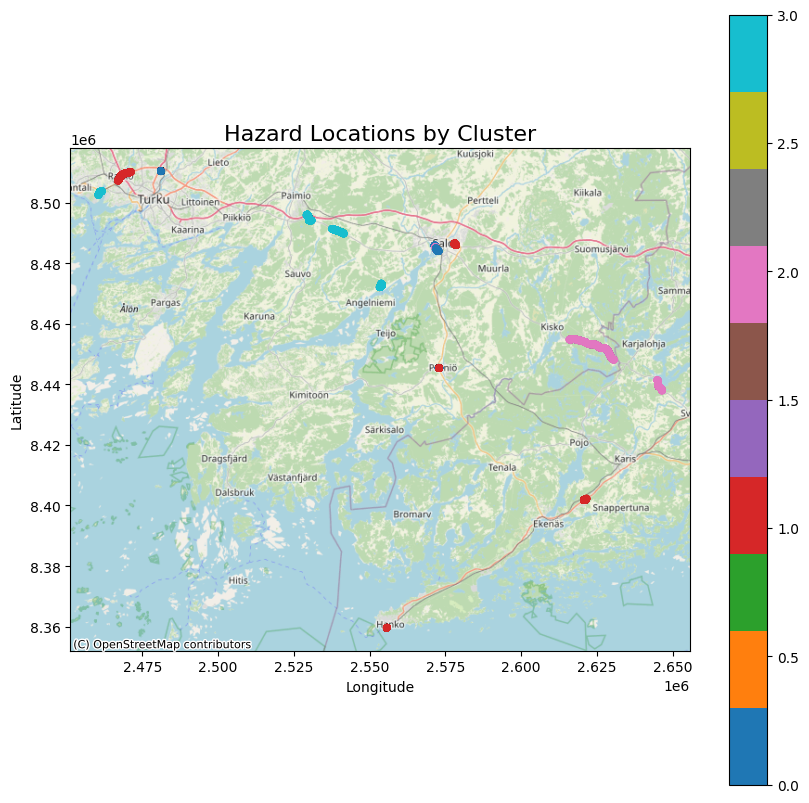

In [4]:
plt.figure(figsize=(10, 10))

ax = plt.gca()
gdf.plot(column="cluster", cmap="tab10", markersize=20, alpha=0.6, ax=ax, legend=True)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title("Hazard Locations by Cluster", fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

Hazard Density Heatmap (KDE)

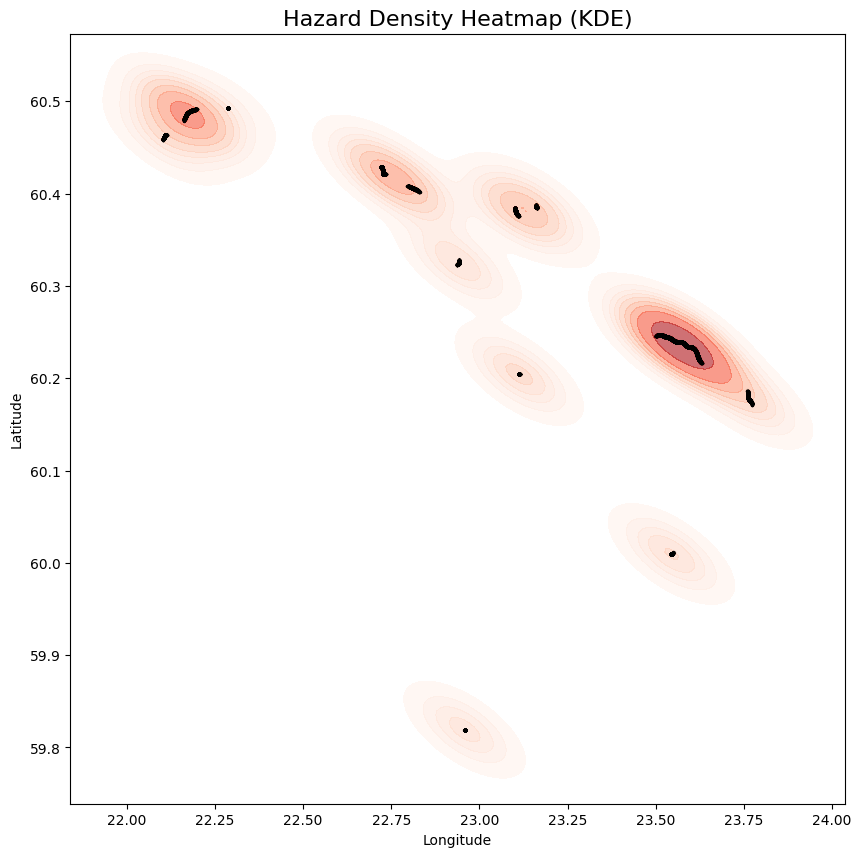

In [5]:
plt.figure(figsize=(10, 10))

sns.kdeplot(
    x=df["lon"], y=df["lat"],
    cmap="Reds", fill=True, alpha=0.6, thresh=0.05
)

plt.scatter(df["lon"], df["lat"], s=2, alpha=0.2, color="black")
plt.title("Hazard Density Heatmap (KDE)", fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Hazard Density on Real Map

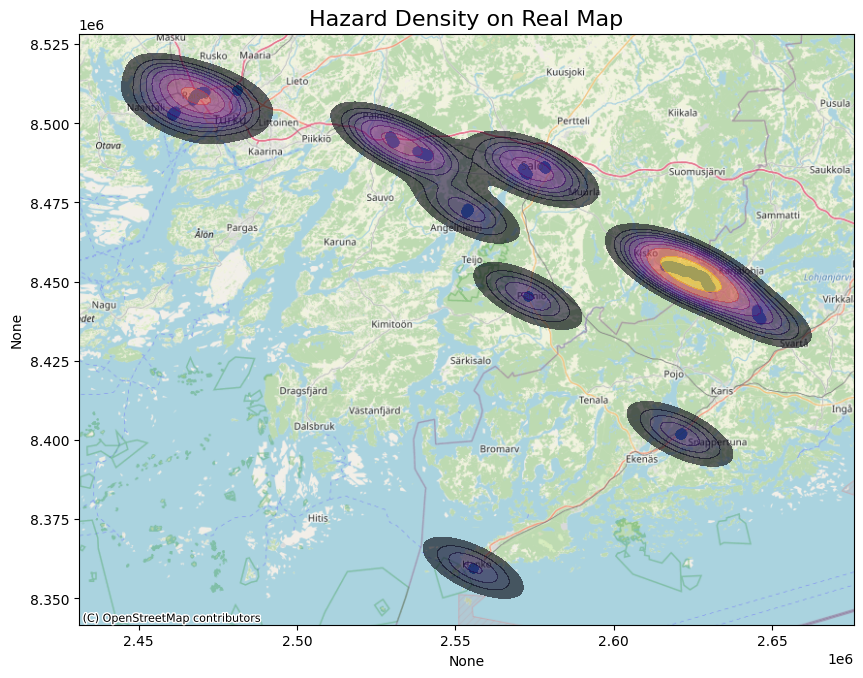

In [6]:
plt.figure(figsize=(10, 10))
ax = plt.gca()

# convert to web mercator for basemap
gdf.plot(ax=ax, alpha=0.01)  # empty plot to fix CRS

sns.kdeplot(
    x=gdf.geometry.x, y=gdf.geometry.y,
    cmap="inferno", fill=True, alpha=0.6, thresh=0.1, ax=ax
)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title("Hazard Density on Real Map", fontsize=16)

plt.show()

Condition-Specific Hazard Maps (Icy Hazards)

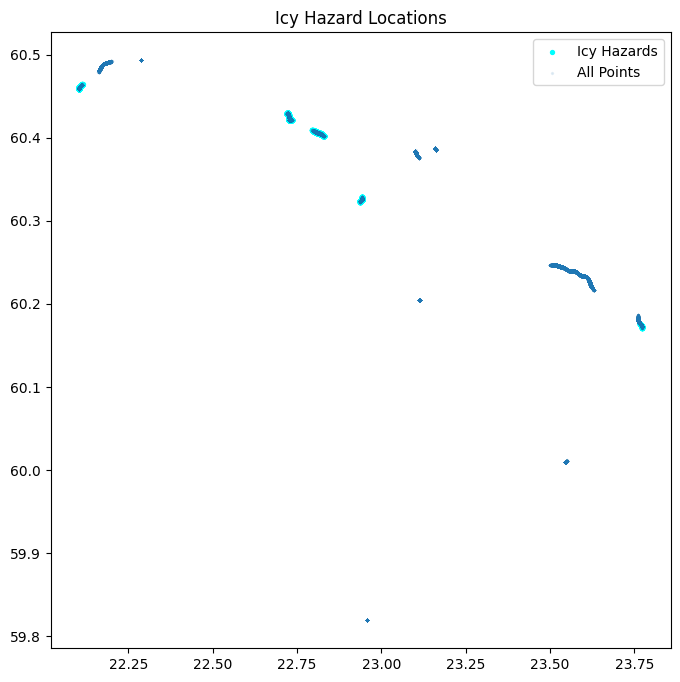

In [7]:
icy = df[df["is_icy"] == True]

plt.figure(figsize=(8, 8))
plt.scatter(icy["lon"], icy["lat"], c="cyan", s=8, label="Icy Hazards")
plt.scatter(df["lon"], df["lat"], s=2, alpha=0.1, label="All Points")
plt.title("Icy Hazard Locations")
plt.legend()
plt.show()

Condition-Specific Hazard Maps (Slippery Hazards (low grip))

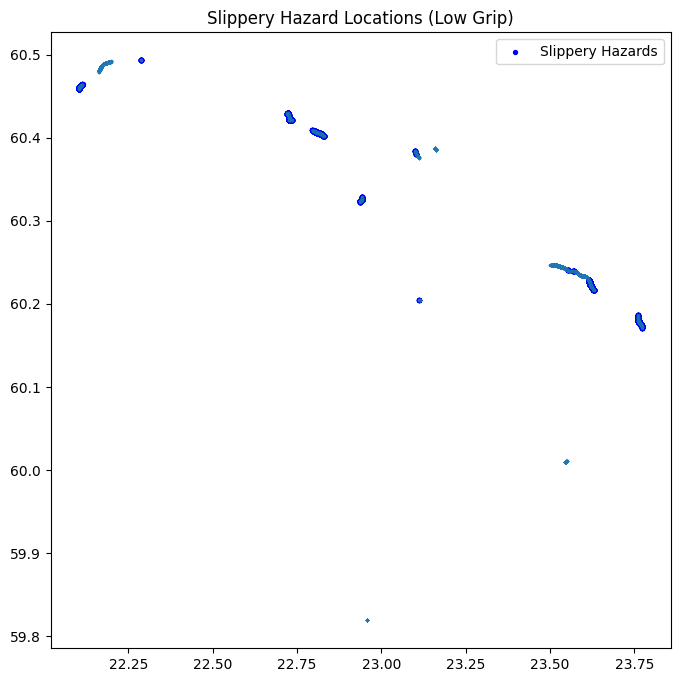

In [8]:
slip = df[df["is_slippery"] == True]

plt.figure(figsize=(8, 8))
plt.scatter(slip["lon"], slip["lat"], c="blue", s=8, label="Slippery Hazards")
plt.scatter(df["lon"], df["lat"], s=2, alpha=0.1)
plt.title("Slippery Hazard Locations (Low Grip)")
plt.legend()
plt.show()

Condition-Specific Hazard Maps (Wet Hazards)

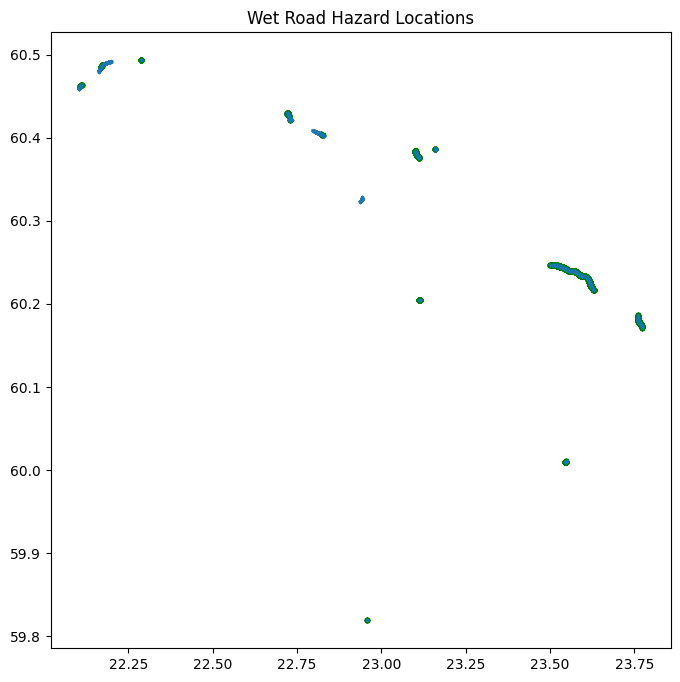

In [9]:
wet = df[df["is_wet"] == True]

plt.figure(figsize=(8, 8))
plt.scatter(wet["lon"], wet["lat"], c="green", s=8)
plt.scatter(df["lon"], df["lat"], s=2, alpha=0.1)
plt.title("Wet Road Hazard Locations")
plt.show()

Condition-Specific Hazard Maps (Hard-Braking Hazards)

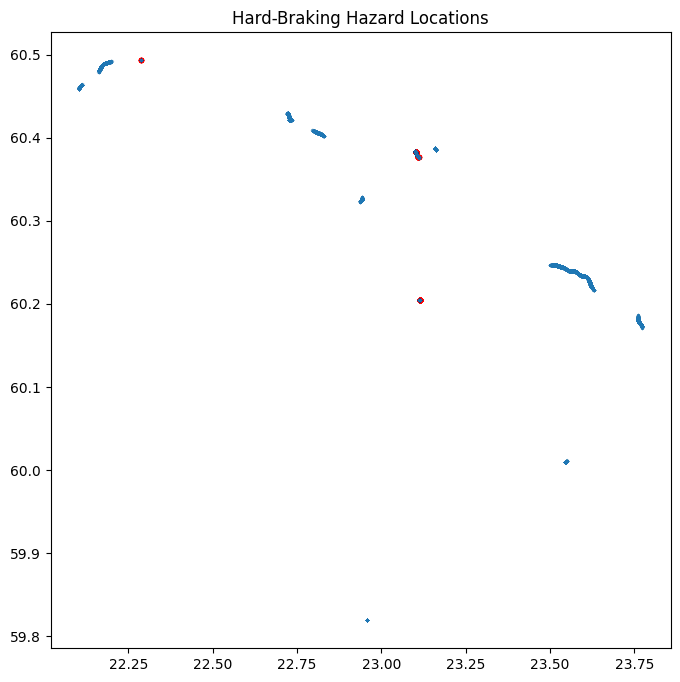

In [10]:
braking = df[df["accx_5s_min"] < df["accx_5s_min"].quantile(0.1)]

plt.figure(figsize=(8, 8))
plt.scatter(braking["lon"], braking["lat"], c="red", s=8)
plt.scatter(df["lon"], df["lat"], s=2, alpha=0.1)
plt.title("Hard-Braking Hazard Locations")
plt.show()

Condition-Specific Hazard Maps (Black Ice Risk Locations)

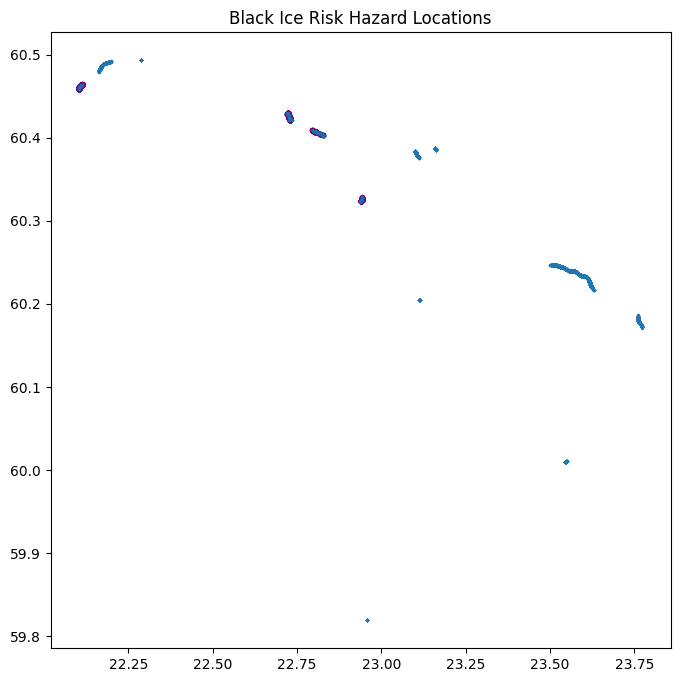

In [11]:
bi = df[df["black_ice_risk"] == 1]

plt.figure(figsize=(8, 8))
plt.scatter(bi["lon"], bi["lat"], c="purple", s=8)
plt.scatter(df["lon"], df["lat"], s=2, alpha=0.1)
plt.title("Black Ice Risk Hazard Locations")
plt.show()

Combined Hazard Map (All Risk Types Together)

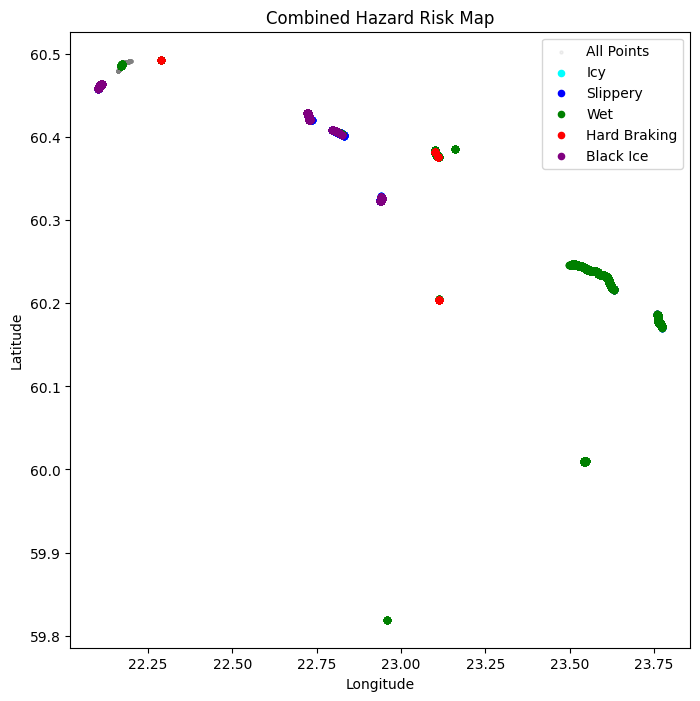

In [12]:
plt.figure(figsize=(8, 8))

plt.scatter(df["lon"], df["lat"], s=5, alpha=0.1, color="gray", label="All Points")
plt.scatter(icy["lon"], icy["lat"], c="cyan", s=20, label="Icy")
plt.scatter(slip["lon"], slip["lat"], c="blue", s=20, label="Slippery")
plt.scatter(wet["lon"], wet["lat"], c="green", s=20, label="Wet")
plt.scatter(braking["lon"], braking["lat"], c="red", s=20, label="Hard Braking")
plt.scatter(bi["lon"], bi["lat"], c="purple", s=20, label="Black Ice")

plt.legend()
plt.title("Combined Hazard Risk Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Combined Hazard Map on Real Map

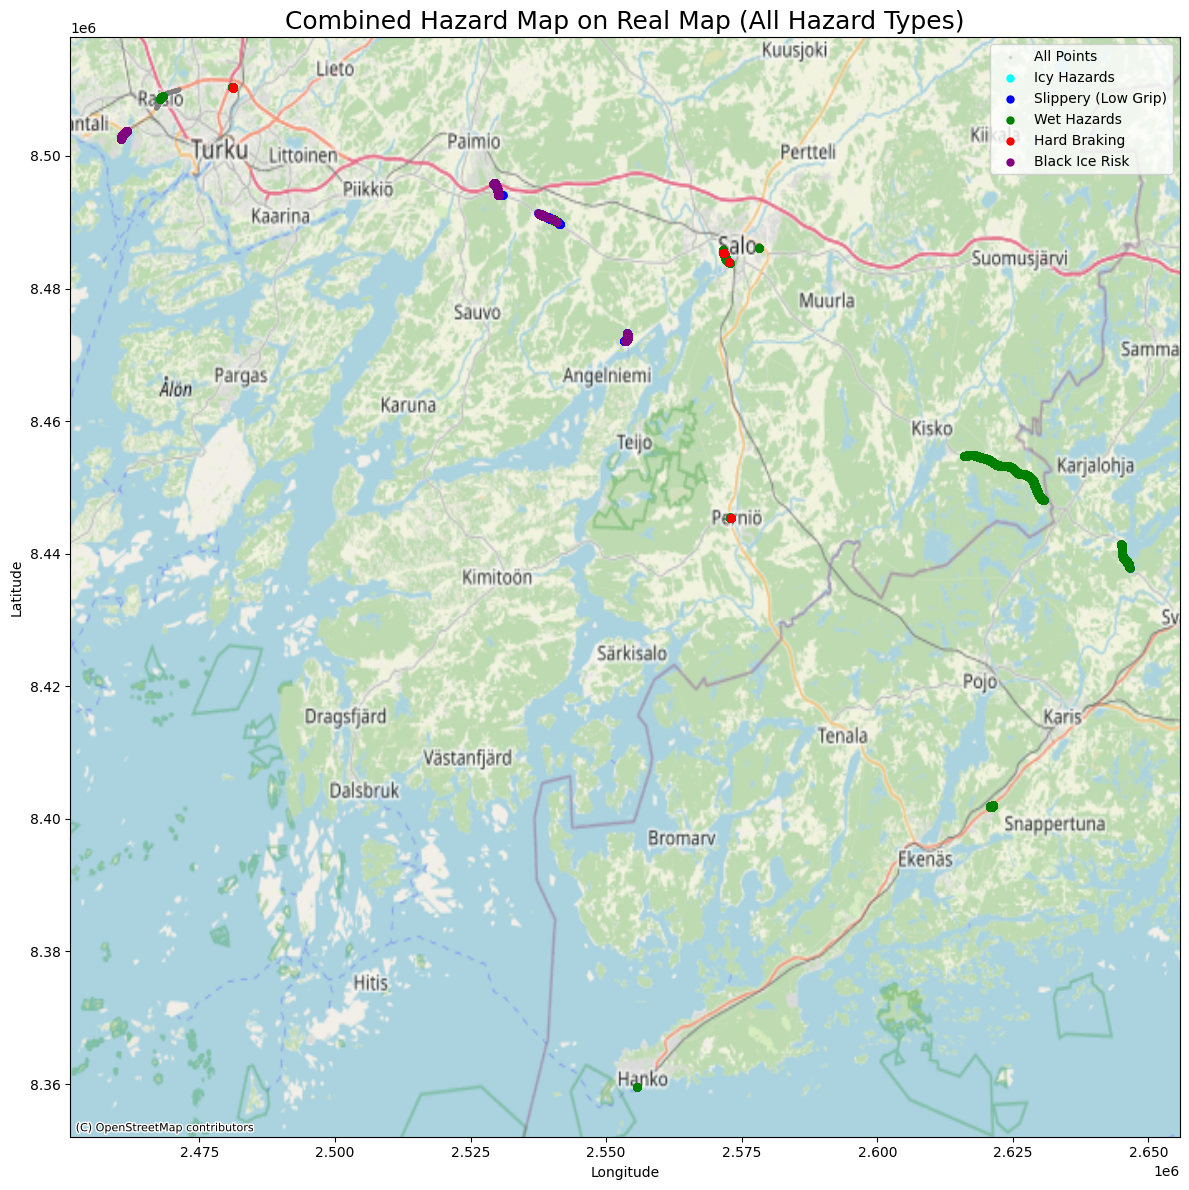

In [13]:



# Remove invalid/missing GPS points
df = df.dropna(subset=["lat", "lon"])
df = df[(df["lat"] != 0) & (df["lon"] != 0)]

# Convert to float (fix mixed dtypes)
df["lat"] = df["lat"].astype(float)
df["lon"] = df["lon"].astype(float)


gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326"   # WGS84 GPS coordinate system
)

# Convert to Web Mercator for contextily
gdf = gdf.to_crs(epsg=3857)



icy = gdf[gdf["is_icy"] == True]
slip = gdf[gdf["is_slippery"] == True]
wet = gdf[gdf["is_wet"] == True]

# Hard braking = lowest 10% accx_5s_min values
braking = gdf[gdf["accx_5s_min"] < gdf["accx_5s_min"].quantile(0.1)]

black_ice = gdf[gdf["black_ice_risk"] == 1]


fig, ax = plt.subplots(figsize=(12, 12))

# --------------------------------------------------
# STEP 1: Plot background points FIRST (important)
# --------------------------------------------------
ax.scatter(
    gdf.geometry.x, gdf.geometry.y,
    s=3, alpha=0.2, color="gray", label="All Points"
)

# --------------------------------------------------
# STEP 2: Plot each hazard type
# --------------------------------------------------
ax.scatter(icy.geometry.x, icy.geometry.y,
           s=25, color="cyan", label="Icy Hazards")

ax.scatter(slip.geometry.x, slip.geometry.y,
           s=25, color="blue", label="Slippery (Low Grip)")

ax.scatter(wet.geometry.x, wet.geometry.y,
           s=25, color="green", label="Wet Hazards")

ax.scatter(braking.geometry.x, braking.geometry.y,
           s=25, color="red", label="Hard Braking")

ax.scatter(black_ice.geometry.x, black_ice.geometry.y,
           s=25, color="purple", label="Black Ice Risk")

# --------------------------------------------------
# STEP 3: Add basemap AFTER plotting (critical)
# --------------------------------------------------
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# --------------------------------------------------
# FINAL STYLING
# --------------------------------------------------
ax.set_title("Combined Hazard Map on Real Map (All Hazard Types)", fontsize=18)
ax.legend(loc="upper right", fontsize=10)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()
